Given

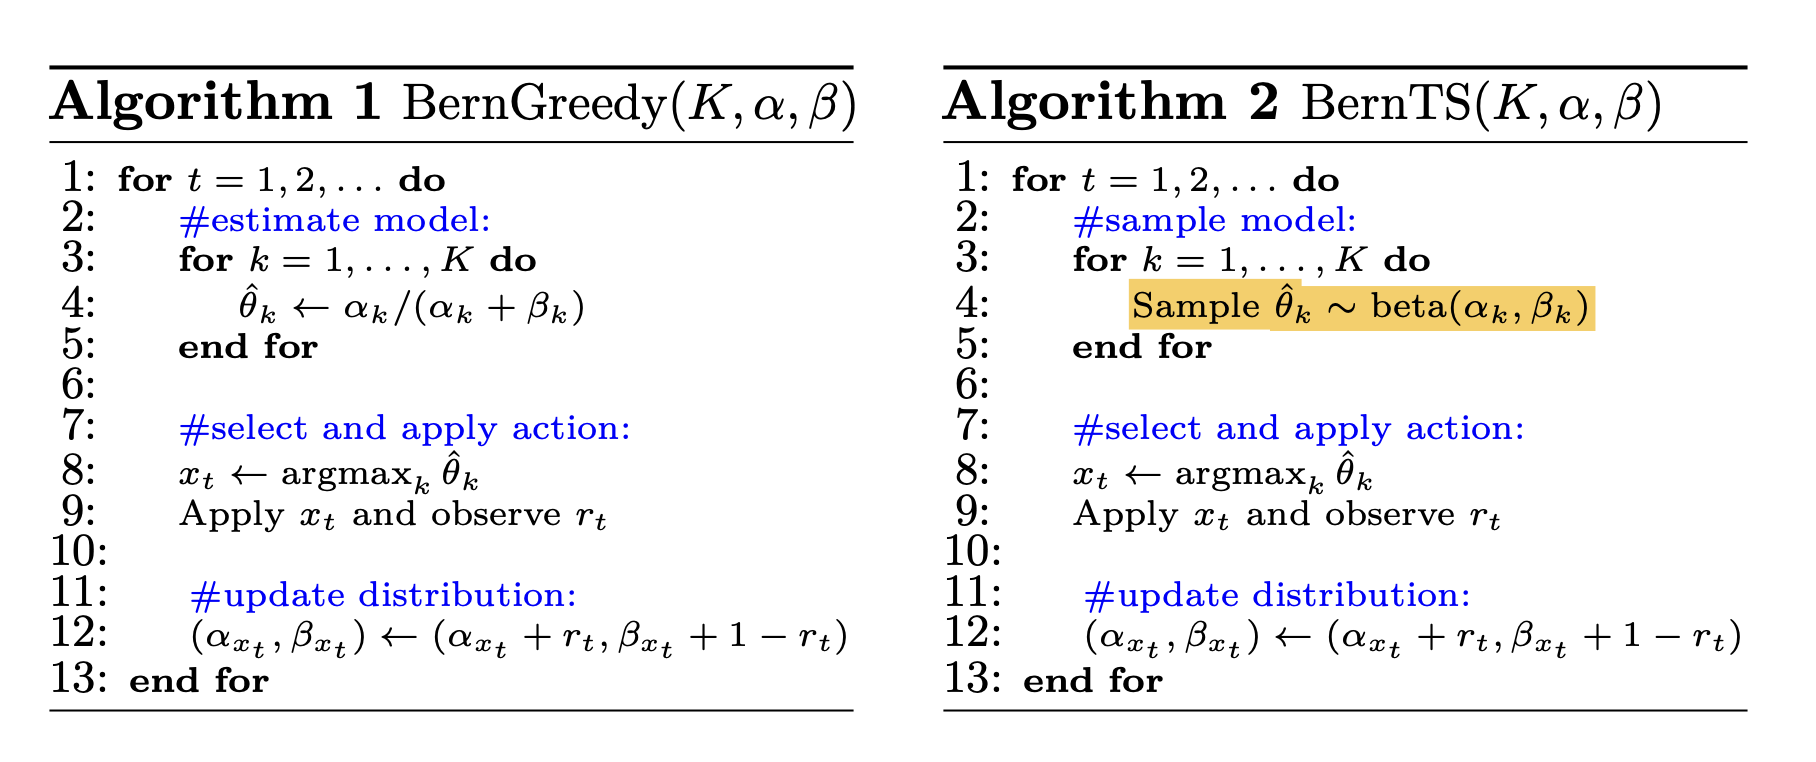
reproduce

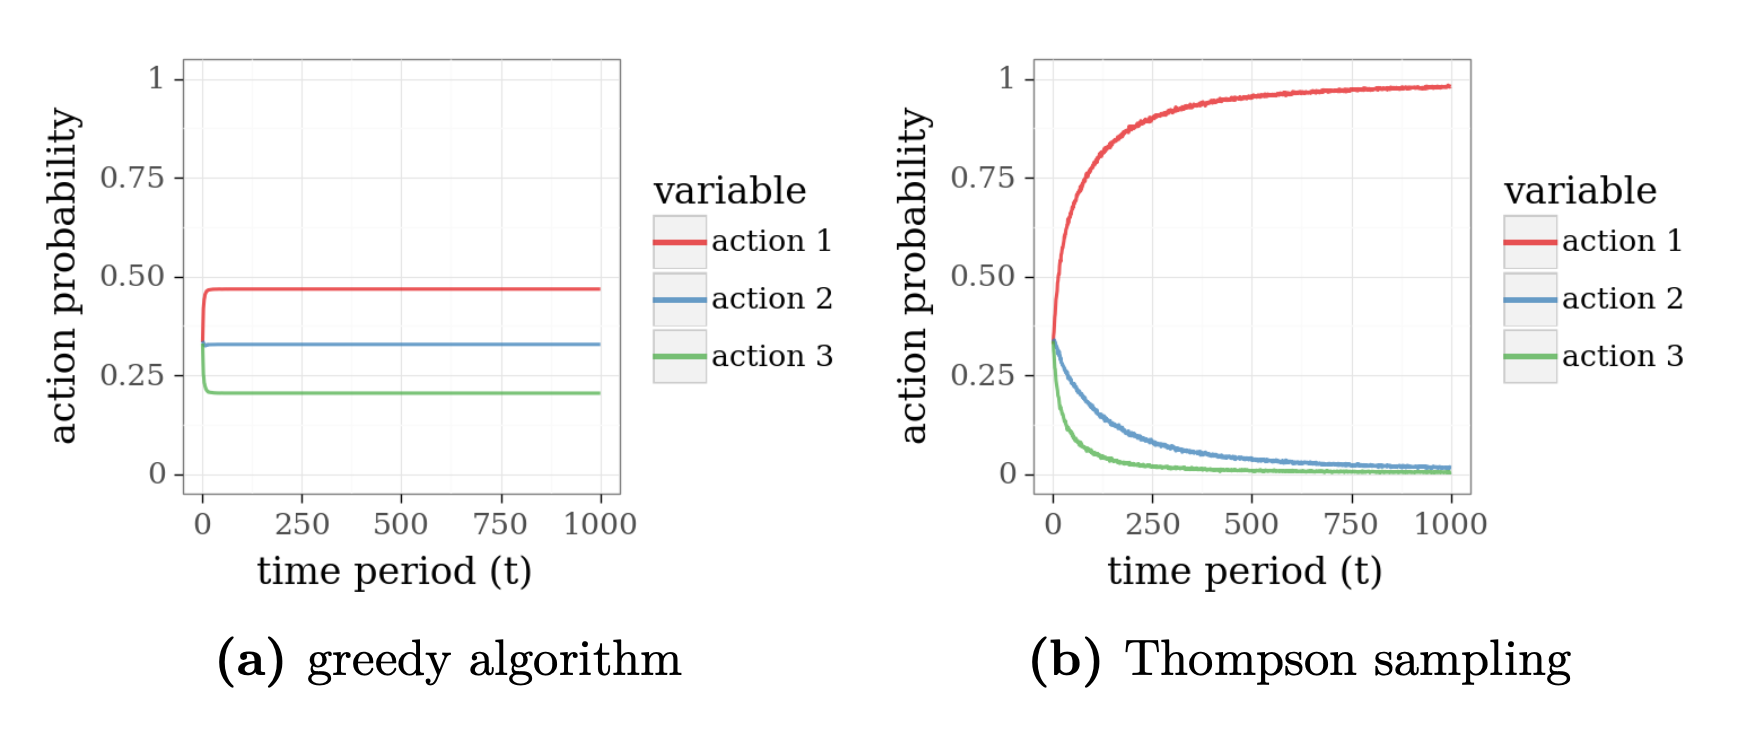

In [1]:
import copy
import multiprocessing
from dataclasses import dataclass

import altair as alt
import matplotlib.pyplot as plt
from scipy import stats
from scipy.integrate import quad
from tqdm import tqdm

In [2]:
def bern_greedy(beta_dists, thetas):
    num_arms = len(thetas)
    means = np.array([a / (a + b) for a, b in beta_dists])

    # Break ties
    indices = np.arange(num_arms)
    np.random.shuffle(indices)
    action = indices[np.argmax(means[indices])]
    return action

In [3]:
def bern_thompson_sampling(beta_dists, thetas):
    num_arms = len(thetas)
    mean_samples = np.array(
        [stats.beta(a, b).rvs(size=1).item() for a, b in beta_dists]
    )
    # Break ties
    indices = np.arange(num_arms)
    np.random.shuffle(indices)
    action = indices[np.argmax(mean_samples[indices])]
    return action

In [ ]:
%%time
actions_list_map = {}

num_simulations = 10000
num_trials = 1000
thetas = [0.9, 0.8, 0.7]  # Mean reward of each arm
num_arms = len(thetas)

for strategy in ["greedy", "thompson_sampling"]:
    actions_list = []
    for _ in tqdm(range(num_simulations)):
        beta_dists = [[1, 1], [1, 1], [1, 1]]  # Beta distributions
        actions = []
        for _ in range(num_trials):

            # Calculate expected rewards per arm.
            if strategy == "greedy":
                expected_rewards = np.array([a / (a + b) for a, b in beta_dists])
            elif strategy == "thompson_sampling":
                expected_rewards = np.array(
                    [stats.beta(a, b).rvs(size=1).item() for a, b in beta_dists]
                )
            else:
                raise ValueError(f"unknown strategy: {strategy}")

            # Break ties
            indices = np.arange(num_arms)
            np.random.shuffle(indices)
            action = indices[np.argmax(expected_rewards[indices])]

            reward = stats.bernoulli.rvs(thetas[action], size=1)[0].item()
            beta_dists[action][0] += reward
            beta_dists[action][1] += 1 - reward

            actions.append(action)
        actions_list.append(actions)

    actions_list_map[strategy] = actions_list

 13%|█████████████▏                                                                                       | 1308/10000 [01:42<12:10, 11.90it/s]

In [9]:
dfs = []
for strategy, actions_list in actions_list_map.items():
    actions_mat = np.array(actions_list)

    df_action_probs = pd.DataFrame(
        {
            "action1": (actions_mat == 0).mean(axis=0),
            "action2": (actions_mat == 1).mean(axis=0),
            "action3": (actions_mat == 2).mean(axis=0),
        }
    )

    dfs.append(
        df_action_probs.stack()
        .rename_axis(["t", "action"])
        .to_frame(name="prob")
        .reset_index()
        .assign(strategy=strategy)
    )

In [10]:
df_plot = pd.concat(dfs)

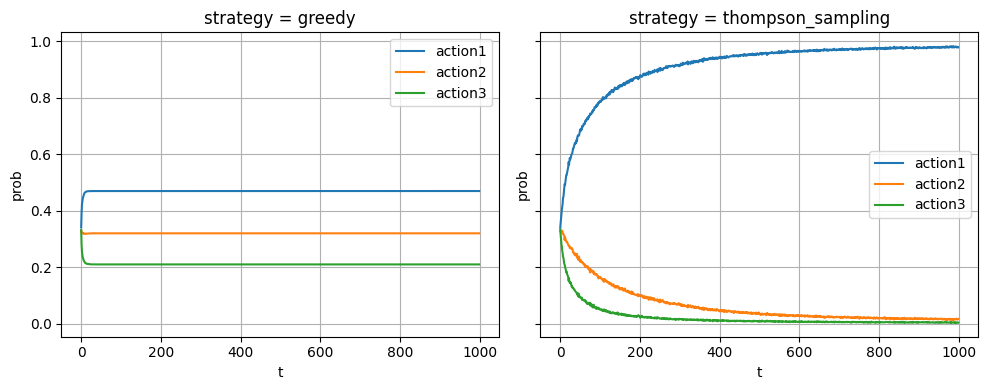

In [11]:
# Get unique strategies
strategies = df_plot["strategy"].unique()

# Create one subplot per strategy (columns)
fig, axes = plt.subplots(
    nrows=1,
    ncols=len(strategies),
    figsize=(5 * len(strategies), 4),
    sharey=True
)

# If only one strategy, axes isn't a list
if len(strategies) == 1:
    axes = [axes]

for ax, strategy in zip(axes, strategies):
    subset = df_plot[df_plot["strategy"] == strategy]
    
    # Plot one line per action
    for action, group in subset.groupby("action"):
        ax.plot(group["t"], group["prob"], label=action)
    
    ax.set_title(f"strategy = {strategy}")
    ax.set_xlabel("t")
    ax.set_ylabel("prob")
    ax.legend()
    ax.grid()

plt.tight_layout()

In [ ]:
# using altair:
# alt.Chart(df_plot).mark_line().encode(x="t", y="prob", color="action").facet(
#     column="strategy"
# )